### A proper ML workflow:

1. **Problem Scoping** 
    a. Use a framework like 4ws to simplify
    b. decide on the problem solution methodology

2. **Data Acquisition**
    a. Secondary sources - kaggle, gov websites, UN websites, github, UCI etc
    b. API - Application Programming Interface
    . 
3. **EDA** 
    – Collect 
    clean data (you already learned EDA / cleaning).
    - Visualise data

4. **Choose a model** – e.g., Decision Tree for classification.

    a. Linear Regression
    b. Logistic Regression
    c. Decision Trees


5. **Train** 
    a. Train, test split, 
    b. Fit the model on training data.

6. **Test**
    a. Make predictions on test data.
    b. Compute metrics (accuracy, etc.)

7. **Improve Performance**
    a. change the split ratio
    b. Change the model Hyper parameters
    c.try different model
    d. EDA again, check if data is perfect for the model
    e. Data acquistion again, add more data or replace the dataset

**Predict House Prices based on house parameters**

1. Predict the house prices, based on various hpusing parameters. 
    - The problem is worth solving, because the real estate professionals often need help in evaluation the prices of properties. 

2. Data Acquisition:
    - Use the inbuilt sci-kit learn dataset 

3. EDA
    - Clean dataset - it is clean already
    - but still recall about cleaning techniques

4. Choose a model:
    - Look into the data and we infer that it is a **Regression Problem**
    - Linear Regression (we are using it here because prices is a continuous value)
    - Next iteration, Logistic Regression *(We will observe this model too. it works on classification problems too)*

5. Training
    - Train-test split of 8:2 - 80% data for training
    - Fit data into the model, model learns the patterns in data

6. Testing
    - Make predictions
    - Observe performance using evaluation metrics
    - Regression evaluation metrics - R2 score, and Mean Absolute Error

7. Improvement
    - Reiterate from a previous step 
    - Training - change the split - Check performance
    - Model - choose a different model - Check performance
    - EDA - clean better, or do feature engineering (create new features etc) -Check performance
    - Data acquisition (change data set) -Check performance

[Scikit Learn Dataset](https://scikit-learn.org/stable/datasets/real_world.html)

## **Step 2: Data Acquisition
[Kaggle California Housing Dataset Link](https://www.kaggle.com/datasets/camnugent/california-housing-prices)

In [2]:
import pandas as pd

from sklearn.datasets import fetch_california_housing

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Training 
from sklearn.model_selection import train_test_split

#Machine Learning
from sklearn.linear_model import LinearRegression,LogisticRegression

#Model Evaluation
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:

housing_data = fetch_california_housing()
housing_data.feature_names


#input features
df = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)

#target features
df['Price'] = (housing_data.target)

#check the dataset
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# Exercise:

- turn the price columns into 10 thousand units ie multiply all records with 10 thousand
turn them back to one units

In [4]:
# df['Price_new'] =df['Price'] * 10000
# df

#### **About the Dataset:**
- 'MedInc' = Median income of the household in the block - 10s thousands
- `HouseAge` - The age of house in years
- `AveRooms` - # of rooms
- 'AveBedrms' - # of bed rooms
- 'Population' - # of people within the block of the property
- 'Aveoccup' - # of people living in the housing
- 'Latitude' - Location cordinates latitude
- 'Longitude' - Location cordinates longitude

## EDA (Exploratory Data Analysis)
- Explore the data
- Clean the data 
- Visualizations

In [5]:
df.shape

(20640, 9)

In [6]:
df.info() # method mesti ada ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [7]:
#info for each column
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [8]:
# check null values
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [9]:
#data types for each column 
df.dtypes

MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
Price         float64
dtype: object

No cleaning needed. Already cleaned

Visualizations

In [10]:
#specify the default for the visualizations


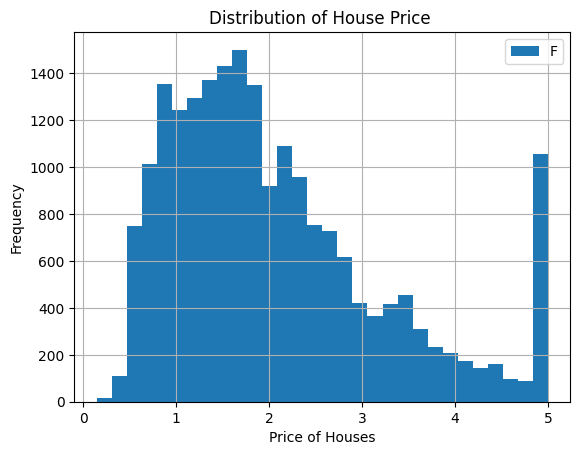

In [11]:
plt.hist(df['Price'],bins=30)

#important stuff u shud always keep for visualisation 
plt.title('Distribution of House Price ')
plt.xlabel('Price of Houses')
plt.ylabel('Frequency')
plt.legend('Frequency')
plt.grid()

plt.show() # untuk keluarkan graph 

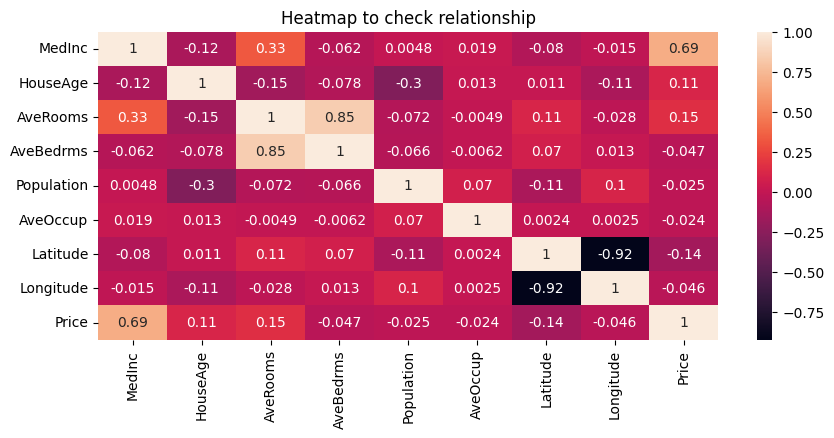

In [12]:
#to know which variable will influence/important the most using correlation
df.corr()
plt.figure(figsize=(10,4))
sns.heatmap(df.corr(),annot=True)
plt.title('Heatmap to check relationship')
plt.show()

#median income has the strong correlation with price 

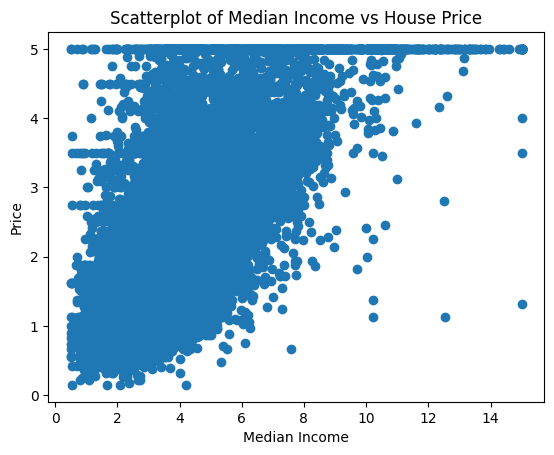

In [13]:
plt.scatter(x=df['MedInc'] ,y=df['Price'] )
plt.title('Scatterplot of Median Income vs House Price')
plt.xlabel('Median Income')
plt.ylabel('Price')

plt.show()

### **Insights**

- ### **Exercise
- To make better visualizations
- Get more insights and record them
- To create all the visualization in a single plot, using subplot and figsize to manipulate visualizations

## Step 4: Choosing the Model

- Choosing Linear Regression -
- How it works 

In [14]:
model = LinearRegression()
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Step 5: Training 

- Train test split of data
- Fit the model with Data

In [15]:
#input features
X = df[['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','Latitude','Longitude']]

#target feature
y = df['Price']

In [27]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: Price, Length: 20640, dtype: float64

In [16]:
X_train = X.iloc[0:15000]
y_train = y.iloc[0:15000]

X_test = X.iloc[15000:]
y_test = y.iloc[15000:]

In [17]:
#using modelselection
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42) # random state take data randomly     

In [18]:
X_train.head()
X_train.shape

(16512, 8)

In [19]:
#fit the data in the model

model.fit(X_train,y_train) # ajar model
# output is hyper parameter

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
model.coef_

array([ 4.48674910e-01,  9.72425752e-03, -1.23323343e-01,  7.83144907e-01,
       -2.02962058e-06, -3.52631849e-03, -4.19792487e-01, -4.33708065e-01])

In [21]:
# check which features came to be the most importance 
feature_importance = pd.DataFrame({
'Features': housing_data.feature_names,
'Model Coefficients':model.coef_
}).sort_values('Model Coefficients', ascending=False)
# how much weight was assigned to each feature 
feature_importance

,Features,Model Coefficients
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


## Step 6: Testing

- Make predictions 
- Evaluation - Calculate the perofmrance of the model 

In [22]:
y_pred = model.predict(X_test)
y_pred

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251], shape=(4128,))

## **Evaluation

In [23]:
# evaluation matrix
r2 = r2_score(y_test, y_pred) # 

mae = mean_absolute_error(y_test,y_pred) #0.53
mae

0.5332001304956555

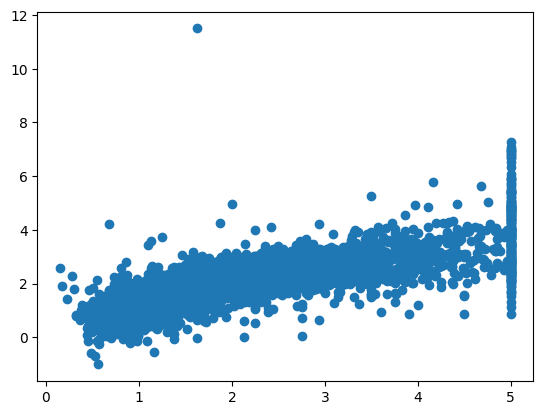

In [24]:
plt.scatter(y_test,y_pred)

In [25]:
#try
model.predict([[8.3252,     41.0, 6.984127, 1.023810, 322.0, 2.555556, 37.88,           -122.23],
               [3.2596 ,	33.0,	5.017657,	1.006421,	2300.0	,3.691814	,32.71,	-117.03],
               [3.2596 ,	33.0,	5.017657,	1.006421,	2300.0	,3.691814	,32.71,	-117.03],
               [3.2596 ,	33.0,	5.017657,	1.006421,	2300.0	,3.691814	,32.71,	-117.03]])

c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([4.15194306, 1.93725874, 1.93725874, 1.93725874])